## Base Models in Bagging (Regression)

In Bagging, multiple base models are trained on different subsets of the same dataset.

- Each model is trained on a **bootstrap sample** (random sampling with replacement)  
- This introduces diversity among models  

---

### Aggregation in Regression

Unlike classification, where predictions are combined using majority voting, regression uses **averaging**.

- Each model makes a prediction  
- Final prediction = **average of all model predictions**

---

###
- Same dataset → different subsets  
- Multiple models → different perspectives  
- Aggregation → more stable output  

---

This process helps reduce variance and improves the reliability of predictions in regression tasks.

### Refrence
[sklearn blog_Baggingregressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingRegressor.html)

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()

X = data.data
y = data.target

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree R2 Score:", r2_score(y_test, y_pred_dt))

Decision Tree R2 Score: 0.622075845135081


In [5]:
from sklearn.ensemble import BaggingRegressor

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bag.fit(X_train, y_train)

y_pred_bag = bag.predict(X_test)

print("Bagging R2 Score:", r2_score(y_test, y_pred_bag))

Bagging R2 Score: 0.8046988456668309


In [6]:
print("Decision Tree R2:", r2_score(y_test, y_pred_dt))
print("Bagging R2      :", r2_score(y_test, y_pred_bag))

Decision Tree R2: 0.622075845135081
Bagging R2      : 0.8046988456668309


##  Final Results & Insights

| Model | R² Score |
|------|---------|
| Decision Tree | 0.62 |
| Bagging Regressor | 0.80 |

---

###  Key Observations

- The Decision Tree model shows lower performance due to high variance  
- Bagging significantly improves performance by averaging multiple models  
- The improvement in R² score demonstrates better generalization  

---

###  Conclusion

Bagging is highly effective for regression tasks, especially when using high-variance models like Decision Trees.

By combining multiple models and averaging their predictions, Bagging produces more stable and accurate results.

---

### 

The greater the variance in the base model, the more benefit Bagging provides.

This makes Bagging a powerful technique for improving regression performance in real-world datasets.

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import r2_score

models = {
    "Decision Tree": BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ),
    
    "Linear Regression": BaggingRegressor(
        estimator=LinearRegression(),
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    ),
    
    "KNN": BaggingRegressor(
        estimator=KNeighborsRegressor(),
        n_estimators=50,
        random_state=42,
        n_jobs=-1
    )
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = r2_score(y_test, y_pred)

results

{'Decision Tree': 0.8036499747356253,
 'Linear Regression': 0.5768111660109387,
 'KNN': 0.1786722263202739}

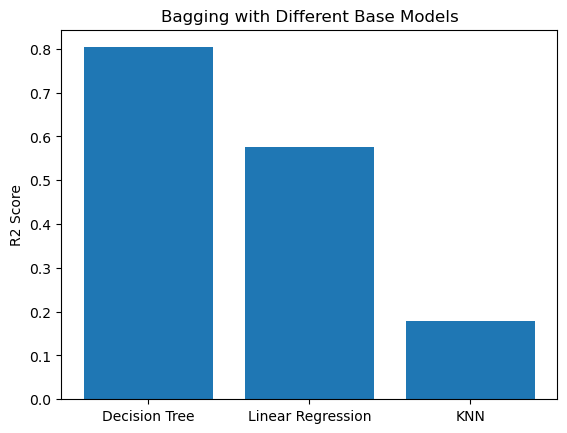

In [8]:
import matplotlib.pyplot as plt

names = list(results.keys())
scores = list(results.values())

plt.figure()
plt.bar(names, scores)

plt.title("Bagging with Different Base Models")
plt.ylabel("R2 Score")

plt.show()

## GridsearchCV 

In [9]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_samples': [0.5, 0.75],
    'max_features': [0.5, 1.0]
}

bag = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    bag,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

In [10]:
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_features': 1.0, 'max_samples': 0.75, 'n_estimators': 100}
Best Score: 0.7989045275976728


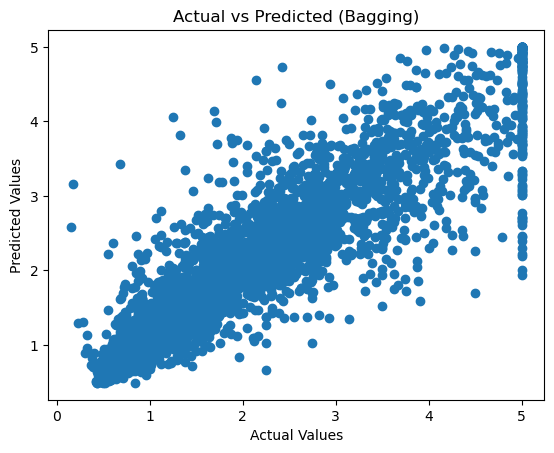

In [14]:
plt.figure()
plt.scatter(y_test, y_pred_bag)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Bagging)")

plt.show()